In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Load the processed data 
df = pd.read_csv('processed_housing_data_final2.csv')

In [11]:
# Check if it loaded correctly
print("Data loaded successfully!")

Data loaded successfully!


In [4]:
print(df.head())

   ID      State       City      Locality      Property_Type  BHK  \
0   3     Punjab   Ludhiana  Locality_167          Apartment    2   
1   4  Rajasthan    Jodhpur  Locality_393  Independent House    2   
2  10  Jharkhand     Ranchi  Locality_122              Villa    2   
3  11  Telangana   Warangal   Locality_75  Independent House    1   
4  12  Karnataka  Bangalore  Locality_462          Apartment    5   

   Size_in_SqFt  Price_in_Lakhs  Price_per_SqFt  Year_Built  ...  \
0          3642          183.79            0.05        1997  ...   
1          2741          300.29            0.11        1991  ...   
2          1393          187.42            0.13        2011  ...   
3           665          324.24            0.49        1991  ...   
4          3988          465.38            0.12        2022  ...   

  Parking_Space  Security                                 Amenities  Facing  \
0           Yes        No          Clubhouse, Pool, Playground, Gym   South   
1           Yes   

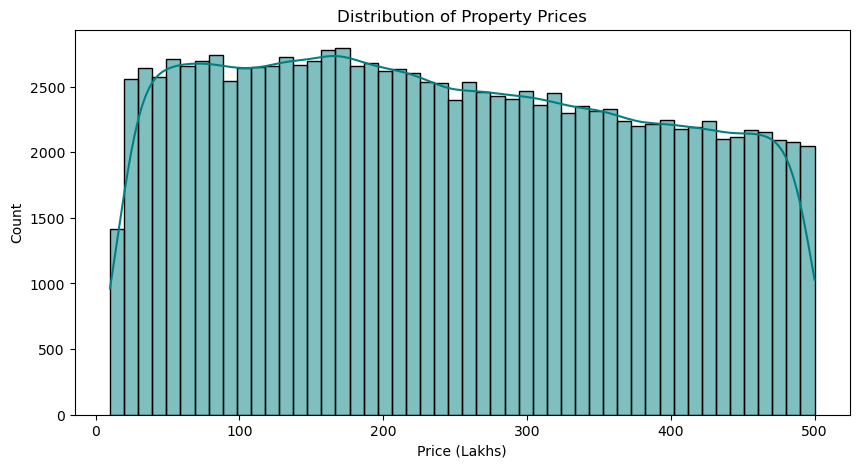

In [12]:
# --- PART 1: PRICE & SIZE ANALYSIS ---

# 1. Distribution of Property Prices
plt.figure(figsize=(10, 5))
sns.histplot(df['Price_in_Lakhs'], bins=50, kde=True, color='teal')
plt.title('Distribution of Property Prices')
plt.xlabel('Price (Lakhs)')
plt.show()

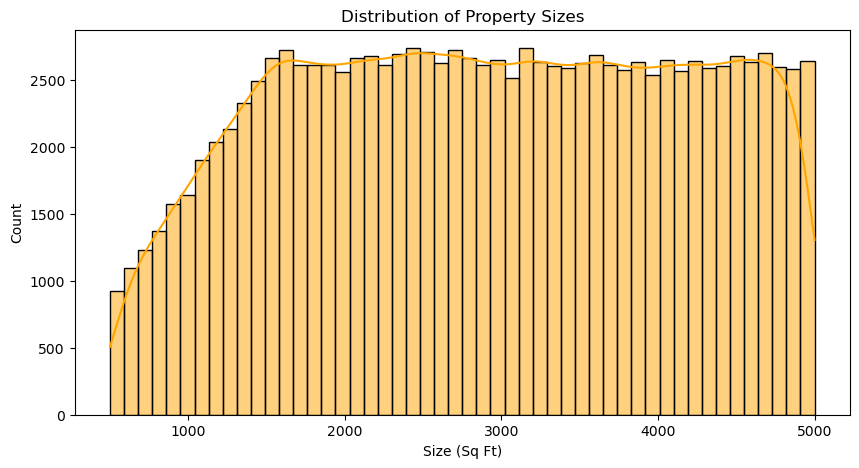

In [13]:
# 2. Distribution of Property Sizes
plt.figure(figsize=(10, 5))
sns.histplot(df['Size_in_SqFt'], bins=50, kde=True, color='orange')
plt.title('Distribution of Property Sizes')
plt.xlabel('Size (Sq Ft)')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_18292\1992039767.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Property_Type', y='Price_per_SqFt', data=df, palette='Set2')


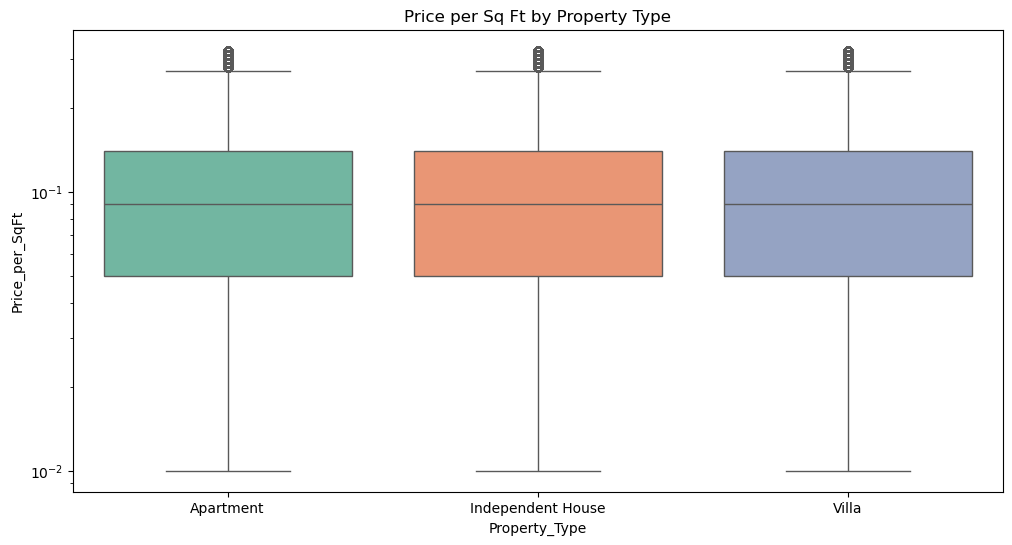

In [14]:
# 3. Price per Sq Ft by Property Type
plt.figure(figsize=(12, 6))
sns.boxplot(x='Property_Type', y='Price_per_SqFt', data=df, palette='Set2')
plt.title('Price per Sq Ft by Property Type')
plt.yscale('log') # Log scale handles wide ranges better
plt.show()

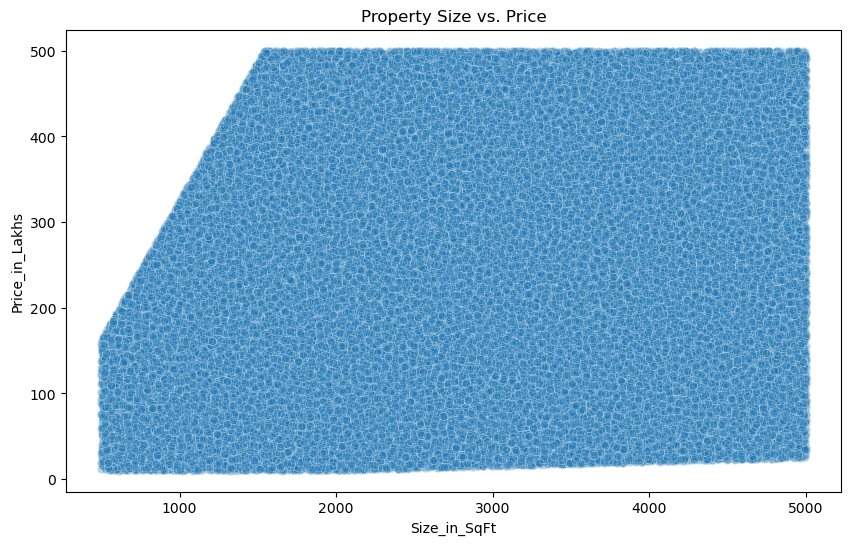

In [15]:
# 4. Relationship between Size and Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Size_in_SqFt', y='Price_in_Lakhs', data=df, alpha=0.3)
plt.title('Property Size vs. Price')
plt.show()

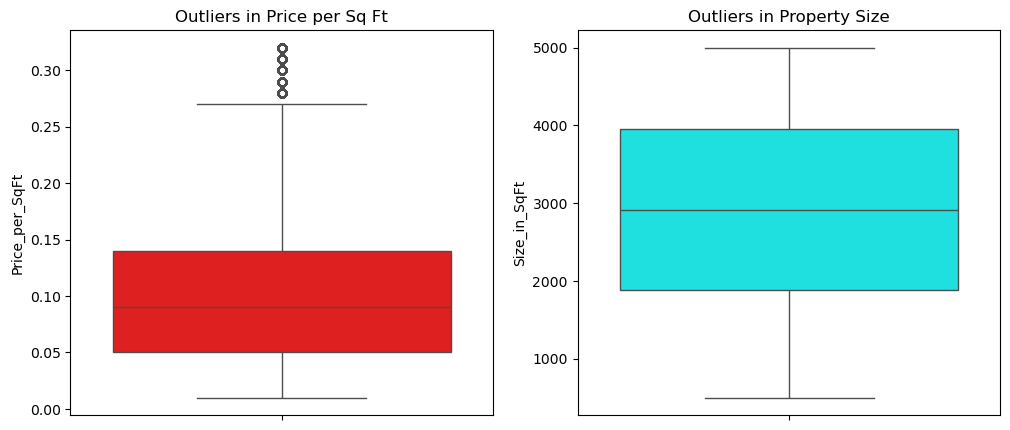

In [16]:
# 5. Outlier Detection (using Boxplots)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Price_per_SqFt'], color='red')
plt.title('Outliers in Price per Sq Ft')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Size_in_SqFt'], color='cyan')
plt.title('Outliers in Property Size')
plt.show()

In [17]:
df[['Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt']].corr()

,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt
Size_in_SqFt,1.000000,0.153268,-0.544353
Price_in_Lakhs,0.153268,1.000000,0.625397
Price_per_SqFt,-0.544353,0.625397,1.000000


In [19]:
df.groupby('Property_Type')[['Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt']].corr()

Size_in_SqFt  Price_in_Lakhs  Price_per_SqFt
Property_Type                                                                 
Apartment         Size_in_SqFt        1.000000        0.151122       -0.545247
                  Price_in_Lakhs      0.151122        1.000000        0.625503
                  Price_per_SqFt     -0.545247        0.625503        1.000000
Independent House Size_in_SqFt        1.000000        0.162019       -0.539947
                  Price_in_Lakhs      0.162019        1.000000        0.623795
                  Price_per_SqFt     -0.539947        0.623795        1.000000
Villa             Size_in_SqFt        1.000000        0.146714       -0.547827
                  Price_in_Lakhs      0.146714        1.000000        0.626884
                  Price_per_SqFt     -0.547827        0.626884        1.000000

In [20]:
df.groupby('City')[['Size_in_SqFt', 'Price_in_Lakhs']].corr()

Size_in_SqFt  Price_in_Lakhs
City                                                       
Ahmedabad      Size_in_SqFt        1.000000        0.170976
               Price_in_Lakhs      0.170976        1.000000
Amritsar       Size_in_SqFt        1.000000        0.141045
               Price_in_Lakhs      0.141045        1.000000
Bangalore      Size_in_SqFt        1.000000        0.160428
...                                     ...             ...
Vijayawada     Price_in_Lakhs      0.162929        1.000000
Vishakhapatnam Size_in_SqFt        1.000000        0.148248
               Price_in_Lakhs      0.148248        1.000000
Warangal       Size_in_SqFt        1.000000        0.160790
               Price_in_Lakhs      0.160790        1.000000

[84 rows x 2 columns]

C:\Users\HP\AppData\Local\Temp\ipykernel_18292\1752083269.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_avg.index, y=state_avg.values, palette='magma')


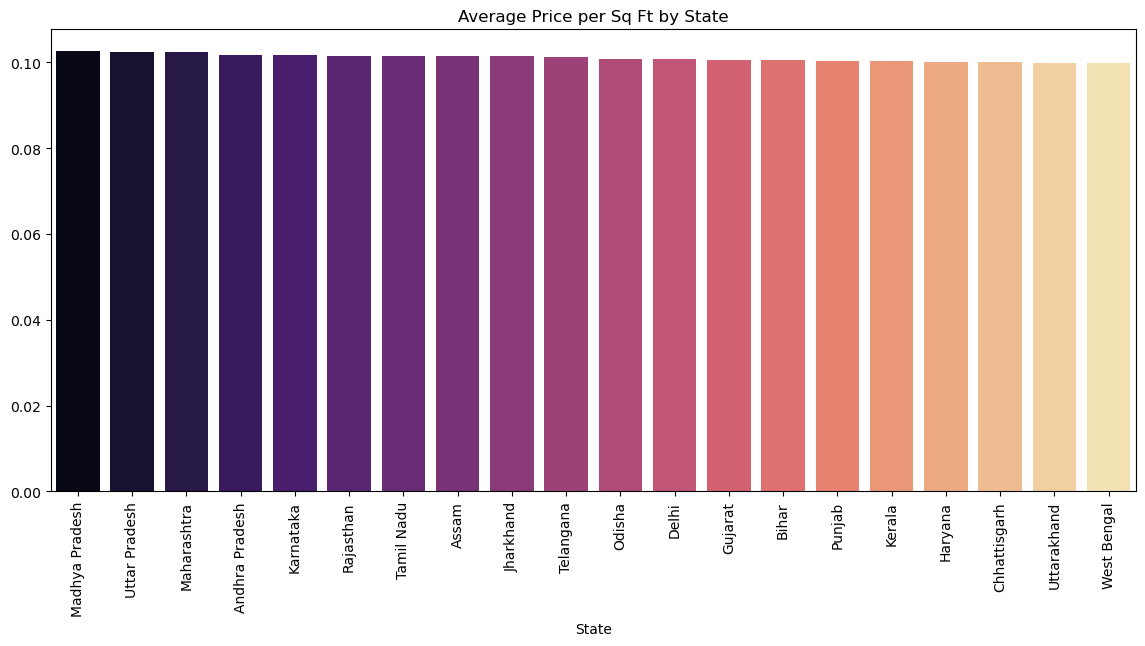

In [21]:
# --- PART 2: LOCATION-BASED ANALYSIS ---

# 6. Avg Price per Sq Ft by State
state_avg = df.groupby('State')['Price_per_SqFt'].mean().sort_values(ascending=False)
plt.figure(figsize=(14, 6))
sns.barplot(x=state_avg.index, y=state_avg.values, palette='magma')
plt.title('Average Price per Sq Ft by State')
plt.xticks(rotation=90)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_18292\3555229840.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_avg.index, y=city_avg.values, palette='coolwarm')


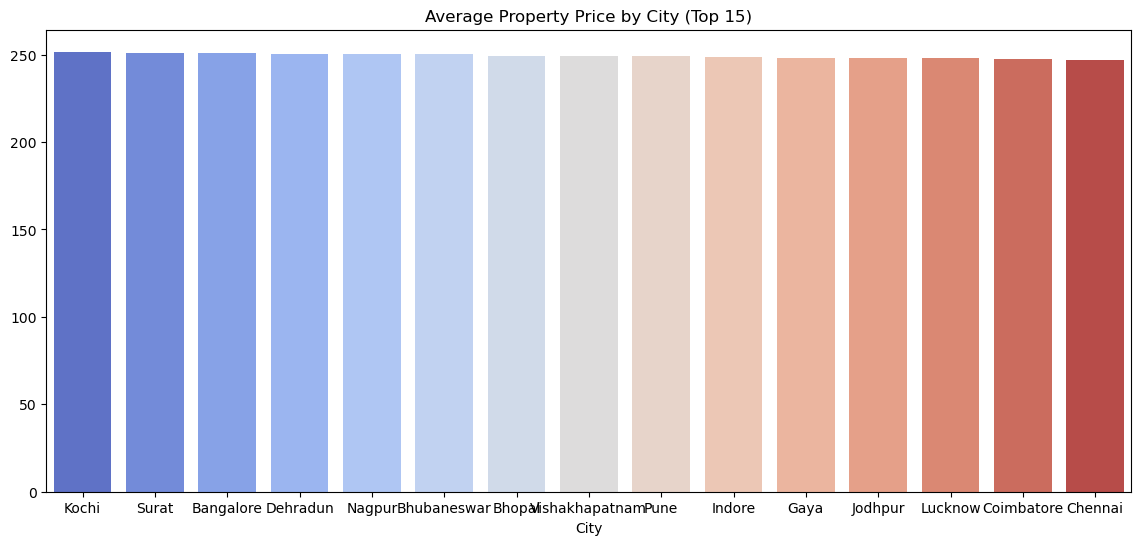

In [22]:
# 7. Avg Property Price by City (Top 15)
city_avg = df.groupby('City')['Price_in_Lakhs'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(14, 6))
sns.barplot(x=city_avg.index, y=city_avg.values, palette='coolwarm')
plt.title('Average Property Price by City (Top 15)')
plt.show()

In [23]:
# 8. Median Age of Properties by Locality (Top 10 Oldest)
df['Property_Age'] = 2024 - df['Year_Built']
locality_age = df.groupby('Locality')['Property_Age'].median().sort_values(ascending=False).head(10)
print("Top 10 Oldest Localities (Median Age):")
print(locality_age)

Top 10 Oldest Localities (Median Age):
Locality
Locality_99     20.0
Locality_124    20.0
Locality_437    20.0
Locality_68     20.0
Locality_107    20.0
Locality_127    20.0
Locality_72     20.0
Locality_198    20.0
Locality_269    20.0
Locality_58     20.0
Name: Property_Age, dtype: float64


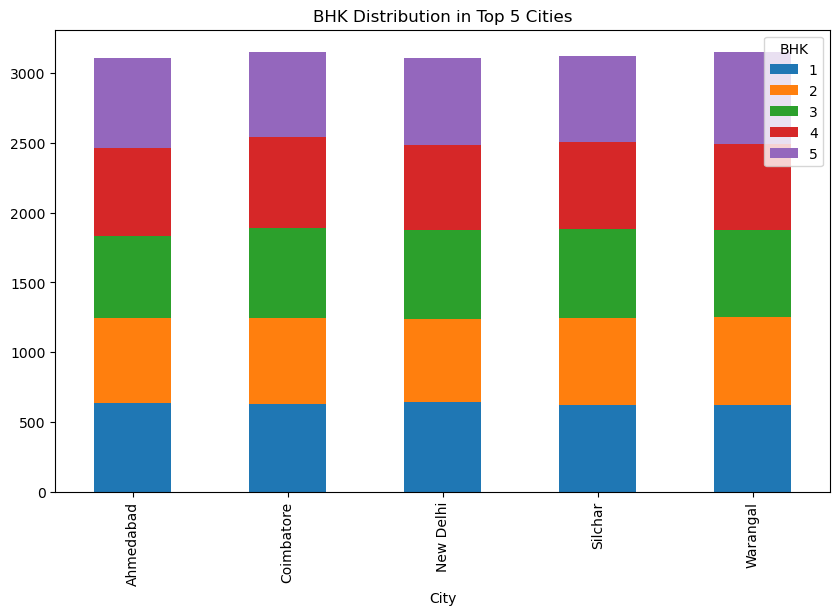

In [24]:
# 9. BHK Distribution across Cities (Stacked Bar)
top_cities = df['City'].value_counts().head(5).index
bhk_city = df[df['City'].isin(top_cities)].groupby(['City', 'BHK']).size().unstack()
bhk_city.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('BHK Distribution in Top 5 Cities')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_18292\1678908997.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=subset, x='Year_Built', y='Price_in_Lakhs', hue='Locality', ci=None)


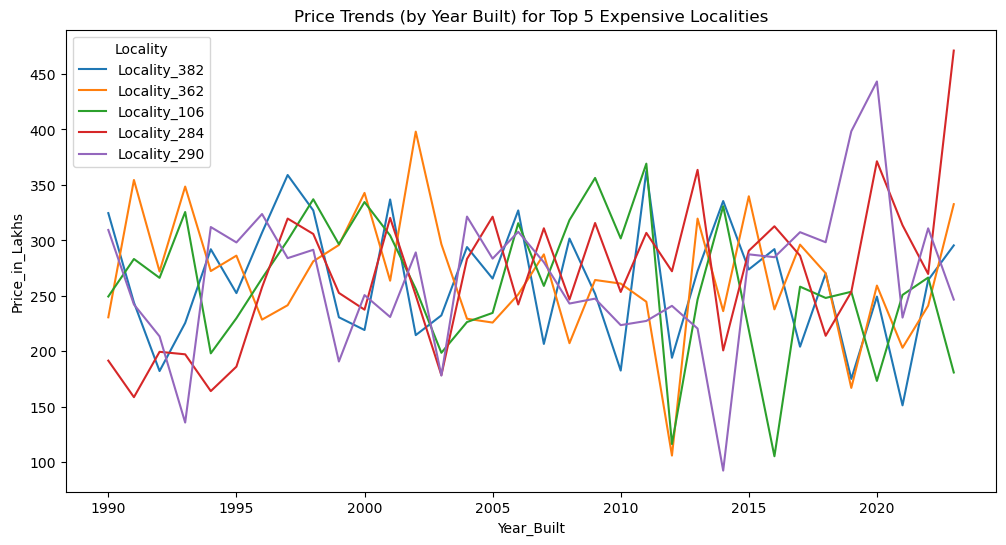

In [25]:
# 10. Price Trends for Top 5 Most Expensive Localities
# (Using Year_Built as a proxy for time trend)
top_5_loc = df.groupby('Locality')['Price_in_Lakhs'].mean().sort_values(ascending=False).head(5).index
subset = df[df['Locality'].isin(top_5_loc)]
plt.figure(figsize=(12, 6))
sns.lineplot(data=subset, x='Year_Built', y='Price_in_Lakhs', hue='Locality', ci=None)
plt.title('Price Trends (by Year Built) for Top 5 Expensive Localities')
plt.show()

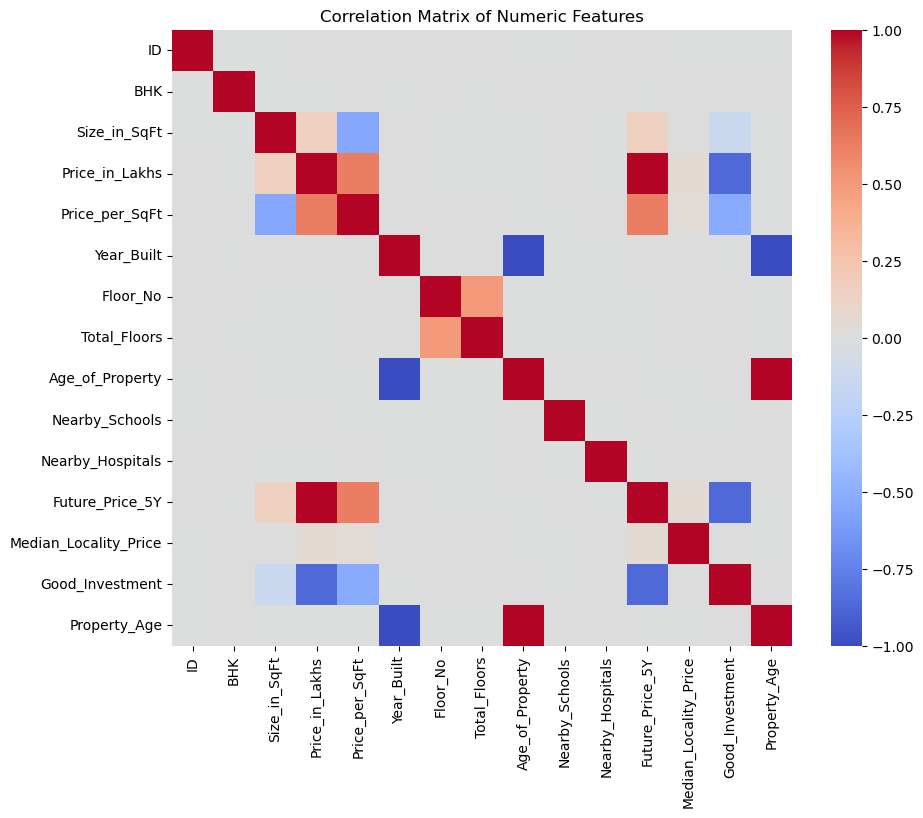

In [26]:
# --- PART 3: FEATURE RELATIONSHIP & CORRELATION ---

# 11. Numeric Correlation Matrix
numeric_cols = df.select_dtypes(include=['number'])
corr_matrix = numeric_cols.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False) # Annot=False to keep it clean
plt.title('Correlation Matrix of Numeric Features')
plt.show()

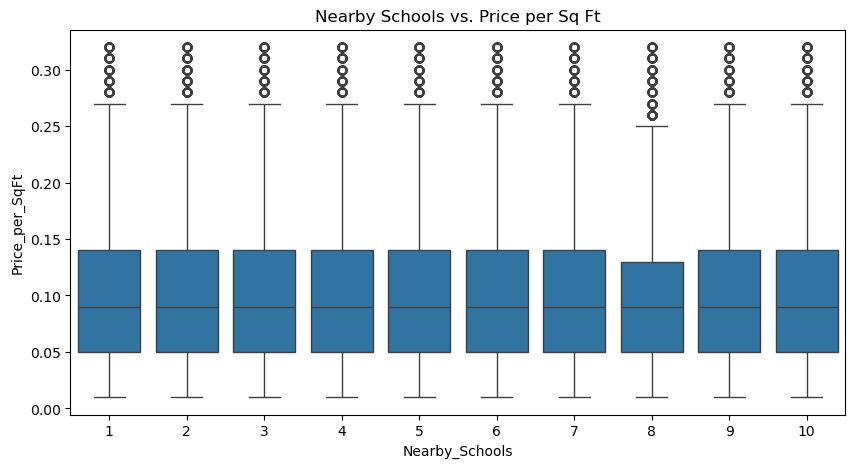

In [27]:
# 12. Nearby Schools vs Price per Sq Ft
plt.figure(figsize=(10, 5))
sns.boxplot(x='Nearby_Schools', y='Price_per_SqFt', data=df)
plt.title('Nearby Schools vs. Price per Sq Ft')
plt.show()

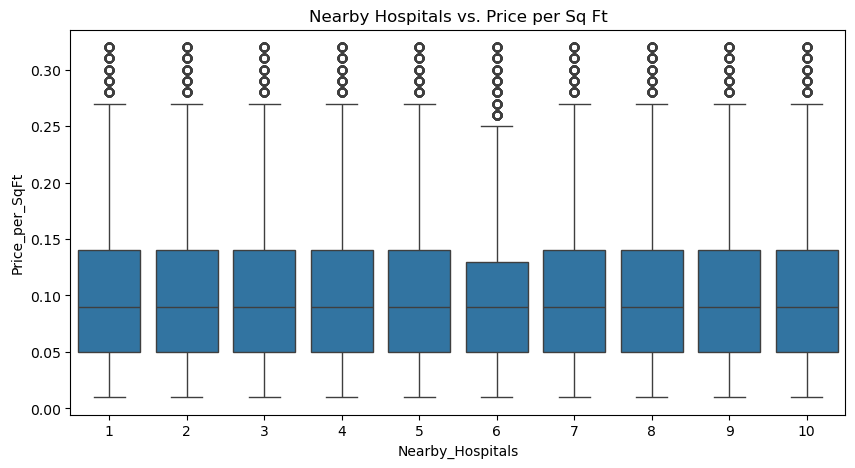

In [28]:
# 13. Nearby Hospitals vs Price per Sq Ft
plt.figure(figsize=(10, 5))
sns.boxplot(x='Nearby_Hospitals', y='Price_per_SqFt', data=df)
plt.title('Nearby Hospitals vs. Price per Sq Ft')
plt.show()

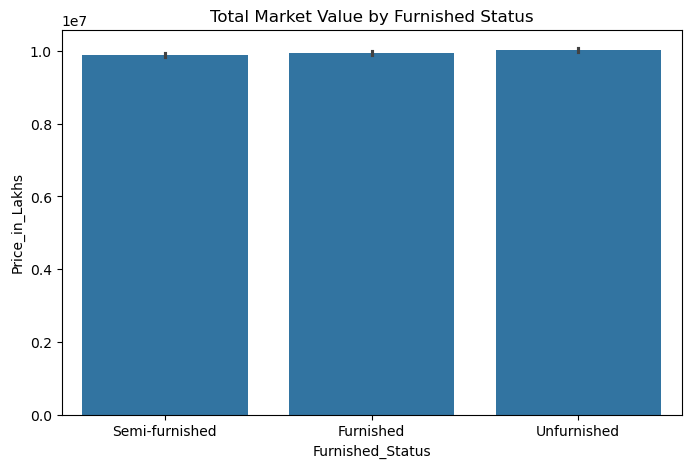

In [29]:
# 14. Price vs Furnished Status
plt.figure(figsize=(8, 5))
sns.barplot(x='Furnished_Status', y='Price_in_Lakhs', data=df, estimator=sum) # or mean
plt.title('Total Market Value by Furnished Status')
plt.show()

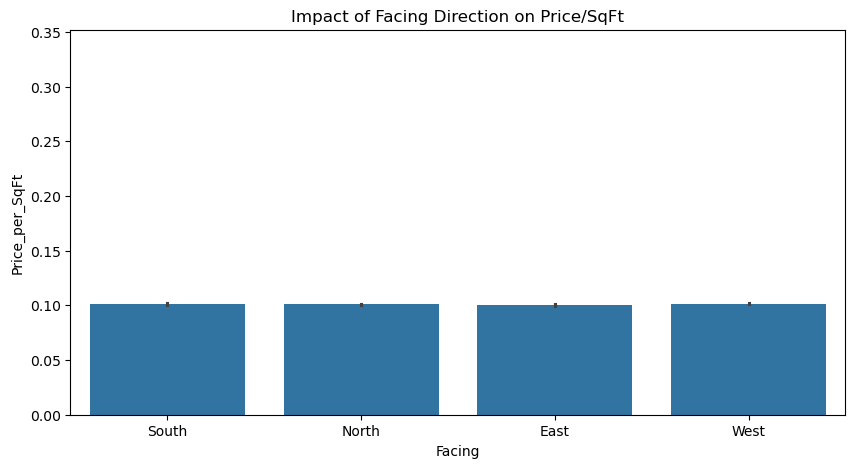

In [30]:
# 15. Facing Direction vs Price per Sq Ft
plt.figure(figsize=(10, 5))
sns.barplot(x='Facing', y='Price_per_SqFt', data=df)
plt.title('Impact of Facing Direction on Price/SqFt')
plt.ylim(0, df['Price_per_SqFt'].max()*1.1) # Adjust scale to see differences
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_18292\2579052995.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Owner_Type', data=df, palette='pastel')


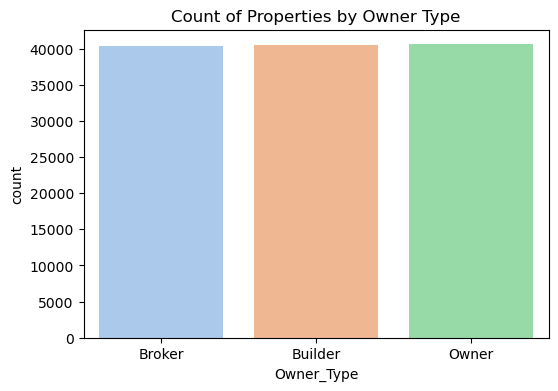

In [31]:
# --- PART 4: INVESTMENT / AMENITIES / OWNERSHIP ---

# 16. Owner Type Count
plt.figure(figsize=(6, 4))
sns.countplot(x='Owner_Type', data=df, palette='pastel')
plt.title('Count of Properties by Owner Type')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_18292\186329026.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Availability_Status', data=df, palette='pastel')


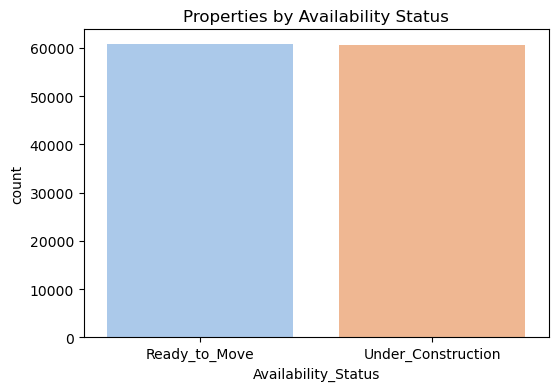

In [32]:
# 17. Availability Status Count
plt.figure(figsize=(6, 4))
sns.countplot(x='Availability_Status', data=df, palette='pastel')
plt.title('Properties by Availability Status')
plt.show()

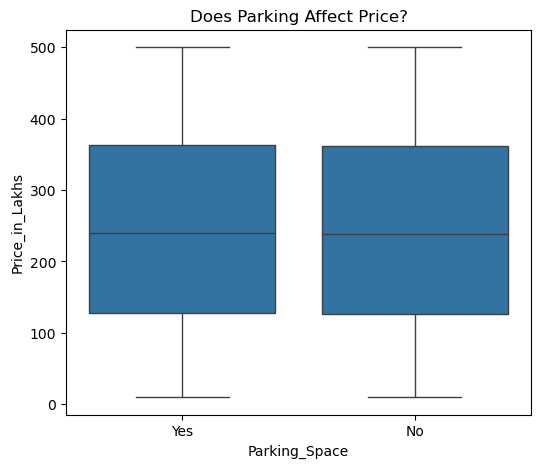

In [33]:
# 18. Parking Space vs Price
plt.figure(figsize=(6, 5))
sns.boxplot(x='Parking_Space', y='Price_in_Lakhs', data=df)
plt.title('Does Parking Affect Price?')
plt.show()

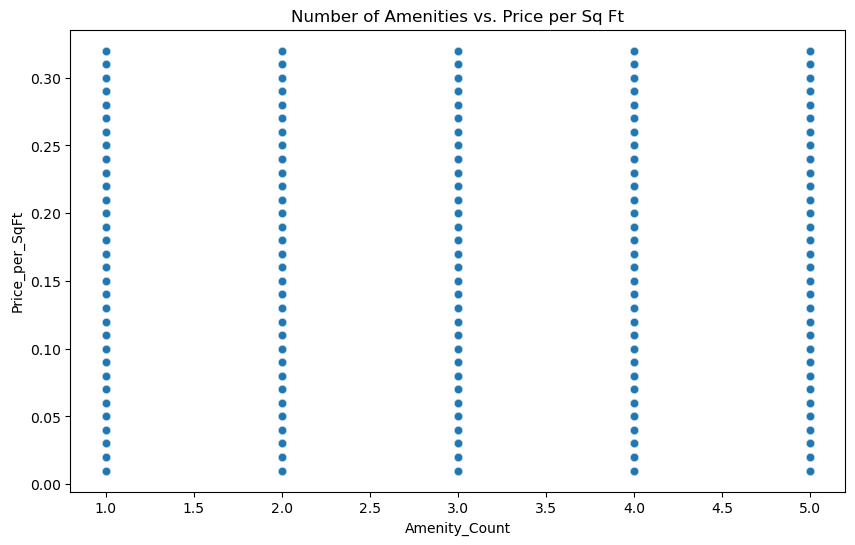

In [34]:
# 19. Amenities vs Price (Feature Engineering needed)
# Calculate number of amenities per property
df['Amenity_Count'] = df['Amenities'].apply(lambda x: len(x.split(',')) if isinstance(x, str) else 0)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Amenity_Count', y='Price_per_SqFt', data=df, alpha=0.5)
plt.title('Number of Amenities vs. Price per Sq Ft')
plt.show()

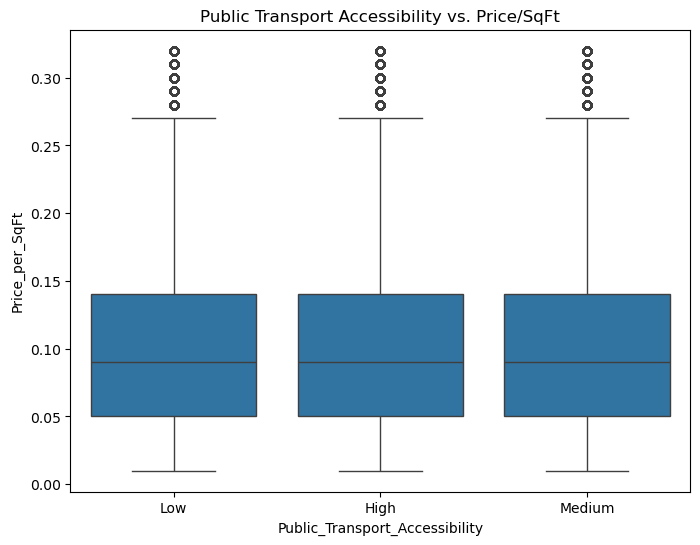

In [35]:
# 20. Public Transport vs Price per Sq Ft
plt.figure(figsize=(8, 6))
sns.boxplot(x='Public_Transport_Accessibility', y='Price_per_SqFt', data=df)
plt.title('Public Transport Accessibility vs. Price/SqFt')
plt.show()